# Import thư viện

In [1]:
! pip install sns


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import pandas as pd
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer

# Load Data

In [3]:
train = pd.read_csv("data_eda/train.csv")
print(f"Tập Train loaded thành công: {train.shape[0]} dòng, {train.shape[1]} cột.")

val = pd.read_csv("data_eda/val.csv")
print(f"Tập Validation loaded thành công: {val.shape[0]} dòng, {val.shape[1]} cột.")

test = pd.read_csv("data_eda/test.csv")
print(f"Tập Test loaded thành công: {test.shape[0]} dòng, {test.shape[1]} cột.")

gc.collect()


Tập Train loaded thành công: 9672932 dòng, 42 cột.
Tập Validation loaded thành công: 2072771 dòng, 42 cột.
Tập Test loaded thành công: 2072772 dòng, 42 cột.


24

# DATA UNDERSTANDING

In [4]:
print(train.info())
display(train.describe())


<class 'pandas.DataFrame'>
RangeIndex: 9672932 entries, 0 to 9672931
Data columns (total 42 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   month                   int64  
 1   day_of_month            int64  
 2   day_of_week             int64  
 3   origin                  float64
 4   dest                    float64
 5   crs_elapsed_time        float64
 6   distance                float64
 7   hour                    int64  
 8   minute                  int64  
 9   temperature_2m          float64
 10  surface_pressure        float64
 11  relative_humidity_2m    int64  
 12  wind_speed_10m          float64
 13  wind_direction_10m      int64  
 14  cloud_cover             int64  
 15  weather_Clear_Cloudy    bool   
 16  weather_Rain            bool   
 17  weather_Snow_Ice        bool   
 18  season                  int64  
 19  time_of_day             int64  
 20  is_rush_hour            bool   
 21  weather_severity_score  int64  
 22  is_ba

,month,day_of_month,day_of_week,origin,dest,crs_elapsed_time,distance,hour,minute,temperature_2m,...,wind_speed_10m,wind_direction_10m,cloud_cover,season,time_of_day,weather_severity_score,wind_risk,rush_hour_x_weather,wind_duration_impact,arr_delay
count,9.672932e+06,9.672932e+06,9.672932e+06,9.672932e+06,9.672932e+06,9.672932e+06,9.672932e+06,9.672932e+06,9.672932e+06,9.672932e+06,...,9.672932e+06,9.672932e+06,9.672932e+06,9.672932e+06,9.672932e+06,9.672932e+06,9.672932e+06,9.672932e+06,9.672932e+06,9.672932e+06
mean,6.588851e+00,1.577229e+01,3.989423e+00,6.821429e+00,6.821367e+00,1.477266e+02,8.388029e+02,1.296880e+01,2.694183e+01,1.575927e+01,...,1.058439e+01,1.852741e+02,4.913492e+01,1.532361e+00,1.668716e+00,6.135282e-01,5.541532e+02,2.714372e-01,2.890768e+04,-1.266983e-17
std,3.392816e+00,8.783893e+00,2.010963e+00,3.289041e+00,2.747418e+00,7.256332e+01,5.984345e+02,4.890148e+00,1.824200e+01,1.018375e+01,...,6.347044e+00,9.907361e+01,4.355031e+01,1.102372e+00,8.933814e-01,7.069781e-01,6.599897e+02,9.181657e-01,2.162640e+04,1.000000e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,-1.250227e+01,-1.100760e+01,-6.000000e+01,3.100000e+01,0.000000e+00,0.000000e+00,-4.380000e+01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.578000e+03,-4.008002e+00
25%,4.000000e+00,8.000000e+00,2.000000e+00,4.763335e+00,4.841895e+00,9.400000e+01,4.020000e+02,9.000000e+00,1.000000e+01,9.000000e+00,...,5.900000e+00,1.020000e+02,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,4.300000e+00,0.000000e+00,1.360400e+04,-5.897159e-01
50%,7.000000e+00,1.600000e+01,4.000000e+00,6.112277e+00,6.789520e+00,1.310000e+02,6.890000e+02,1.300000e+01,2.700000e+01,1.680000e+01,...,9.400000e+00,1.910000e+02,4.200000e+01,2.000000e+00,2.000000e+00,0.000000e+00,3.007000e+02,0.000000e+00,2.430720e+04,5.888954e-02
75%,1.000000e+01,2.300000e+01,6.000000e+00,8.890994e+00,9.107550e+00,1.790000e+02,1.072000e+03,1.700000e+01,4.300000e+01,2.340000e+01,...,1.410000e+01,2.650000e+02,1.000000e+02,3.000000e+00,2.000000e+00,1.000000e+00,9.100000e+02,0.000000e+00,3.831600e+04,5.990283e-01
max,1.200000e+01,3.100000e+01,7.000000e+00,3.436444e+01,2.431878e+01,7.390000e+02,5.095000e+03,2.400000e+01,5.900000e+01,4.750000e+01,...,6.350000e+01,3.600000e+02,1.000000e+02,3.000000e+00,3.000000e+00,4.000000e+00,6.230000e+03,1.600000e+01,2.683506e+05,5.931009e+00


# UNIVARIATE ANALYSIS

**Arr_delay**

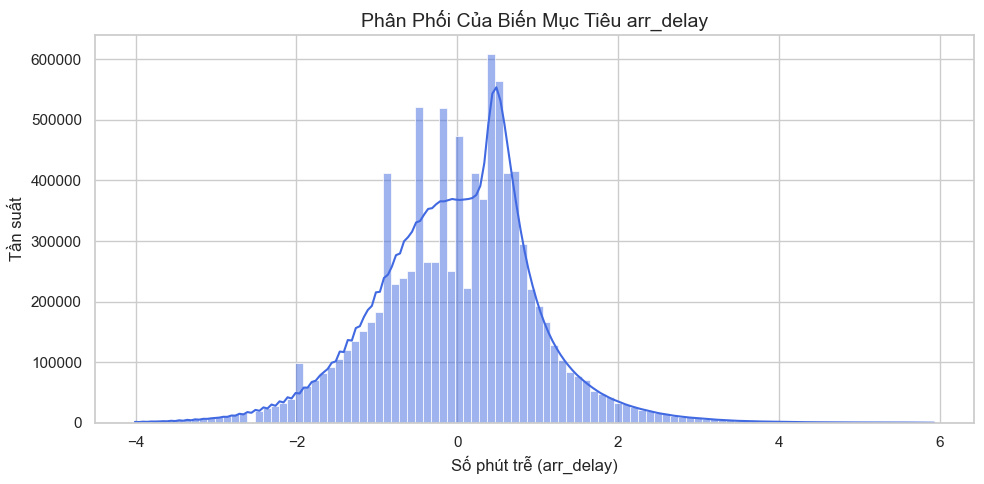

--- Thống kê mô tả của arr_delay ---
count    9.672932e+06
mean    -1.266983e-17
std      1.000000e+00
min     -4.008002e+00
25%     -5.897159e-01
50%      5.888954e-02
75%      5.990283e-01
max      5.931009e+00
Name: arr_delay, dtype: float64
Độ lệch (Skewness): 0.0424
Độ nhọn (Kurtosis): 1.5319


In [6]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

sns.histplot(
    train['arr_delay'],
    bins=100,
    kde=True,
    color='royalblue'
)

plt.title('Phân Phối Của Biến Mục Tiêu arr_delay', fontsize=14)
plt.xlabel('Số phút trễ (arr_delay)')
plt.ylabel('Tần suất')
plt.tight_layout()
plt.show()

print("--- Thống kê mô tả của arr_delay ---")
print(train['arr_delay'].describe())
print(f"Độ lệch (Skewness): {train['arr_delay'].skew():.4f}")
print(f"Độ nhọn (Kurtosis): {train['arr_delay'].kurt():.4f}")

Phản ánh một thực tế rất đặc trưng của ngành hàng không: phần lớn các chuyến bay sẽ hạ cánh đúng giờ hoặc chỉ trễ một vài phút (tập trung sát vạch 0 hoặc số âm nếu đến sớm), nhưng có một số ít chuyến bay gặp sự cố lớn, thời tiết xấu cực đoan dẫn đến số phút trễ kéo dài tới vài trăm hoặc cả nghìn phút (tạo ra cái đuôi rất dài về phía bên phải).

Dùng phương pháp 'yeo-johnson' 

In [4]:
pt = PowerTransformer(method='yeo-johnson', standardize=False)
train['yj_arr_delay'] = pt.fit_transform(train[['arr_delay']])
# Tính độ lệch (Skewness) trước và sau
skew_before = train['arr_delay'].skew()
skew_after = train['yj_arr_delay'].skew()


Độ lệch (Skewness) TRƯỚC biến đổi: 6.4019
Độ lệch (Skewness) SAU biến đổi: 0.0406


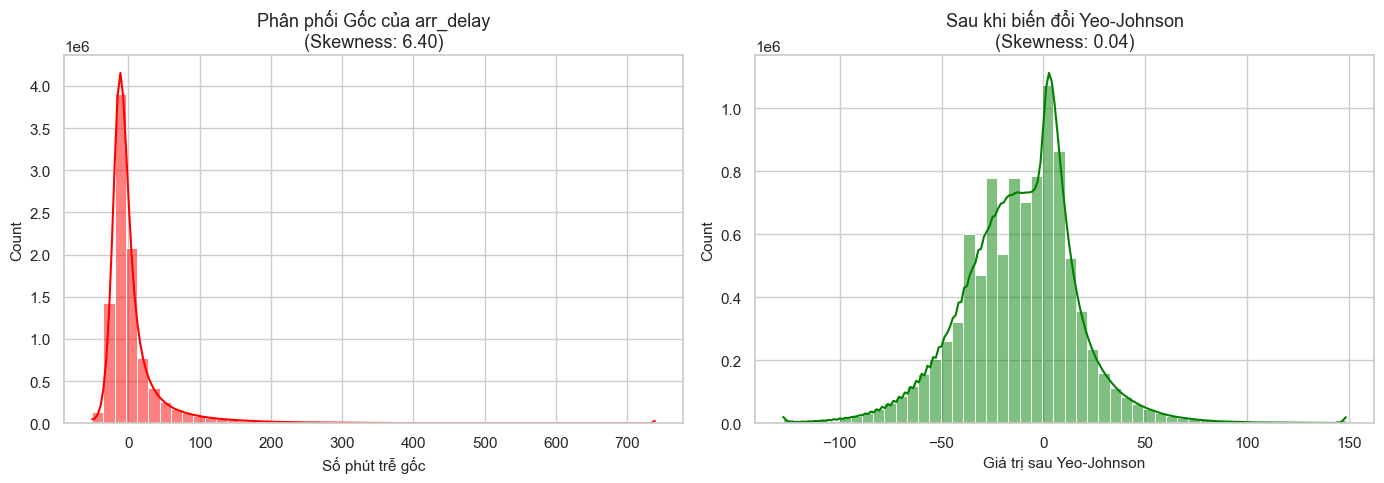

In [ ]:
print(f"Độ lệch (Skewness) TRƯỚC biến đổi: {skew_before:.4f}")
print(f"Độ lệch (Skewness) SAU biến đổi: {skew_after:.4f}")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train['arr_delay'], bins=50, kde=True, ax=axes[0], color='red')
axes[0].set_title(f'Phân phối Gốc của arr_delay\n(Skewness: {skew_before:.2f})', fontsize=13)
axes[0].set_xlabel('Số phút trễ gốc', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)

sns.histplot(train['yj_arr_delay'], bins=50, kde=True, ax=axes[1], color='green')
axes[1].set_title(f'Sau khi biến đổi Yeo-Johnson\n(Skewness: {skew_after:.2f})', fontsize=13)
axes[1].set_xlabel('Giá trị sau Yeo-Johnson', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
plt.tight_layout()
plt.show()

In [5]:
val['yj_arr_delay'] = pt.transform(val[['arr_delay']])
test['yj_arr_delay'] = pt.transform(test[['arr_delay']])

**Nhận xét hiệu quả biến đổi Yeo-Johnson trên biến `arr_delay`**

* **Khắc phục triệt để độ lệch (Skewness):** Chỉ số phân bố giảm mạnh từ 6.40 (lệch phải nghiêm trọng) xuống mức lý tưởng 0.04, đưa dữ liệu về trạng thái gần như đối xứng hoàn hảo.
* **Chuẩn hóa hình thái phân phối:** Chuyển đổi thành công dữ liệu gốc mang đặc tính "đuôi dài" (chứa các chuyến bay trễ cực đoan) thành dạng phân phối chuẩn (Normal Distribution) với hình quả chuông rõ rệt.
* **Tối ưu hóa không gian dữ liệu:** Nén dải giá trị trải rộng từ `[-50, 750]` về thang đo nhỏ gọn `[-100, 150]`, giúp bảo toàn nguyên vẹn các điểm dữ liệu ngoại lệ thực tế (outliers) mà không cần phải xóa bỏ.
* **Tạo tiền đề cho mô hình Học máy:** Phân phối mới giúp triệt tiêu áp lực từ các giá trị trễ quá lớn, tạo điều kiện tối ưu để các thuật toán (đặc biệt là mô hình tuyến tính) hội tụ nhanh, giảm sai số và hoạt động ổn định.

**Các đặc trưng thống kê dựa trên Rolling Target Encoding (_te và _rate)**

Thống kê mô tả các đặc trưng Rolling Target Encoding:


,origin,dest
count,9672932.000,9672932.000
mean,6.821,6.821
std,3.289,2.747
min,-12.502,-11.008
25%,4.763,4.842
50%,6.112,6.790
75%,8.891,9.108
max,34.364,24.319


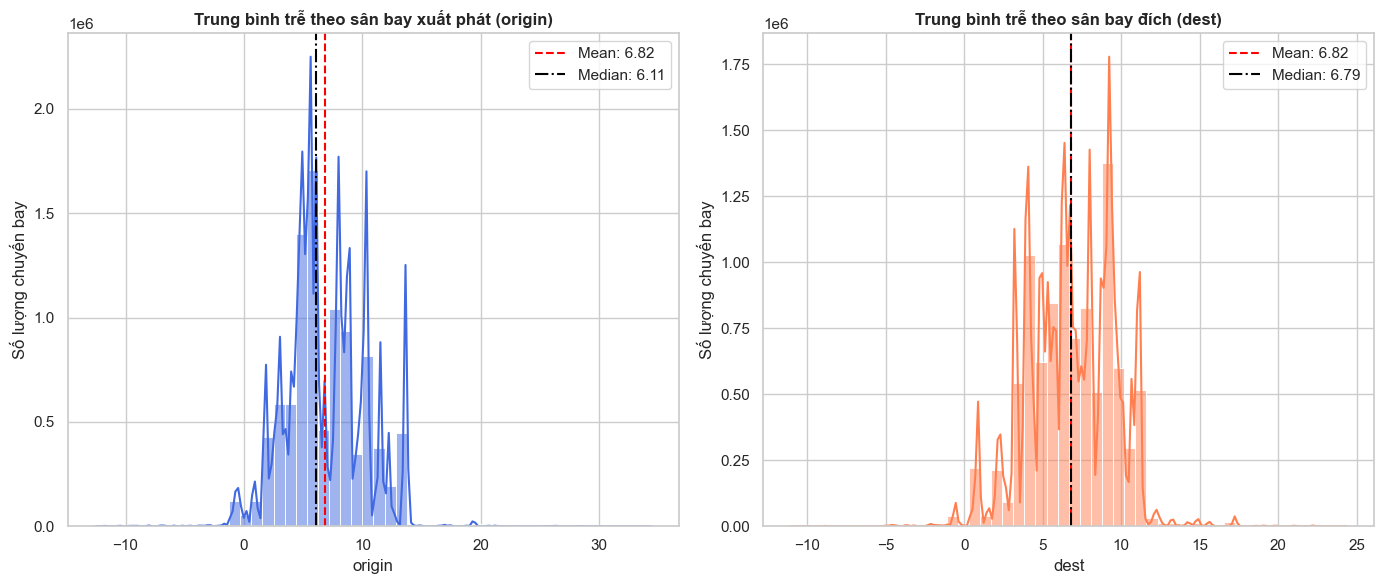

In [9]:
te_features = ['origin', 'dest']

print("Thống kê mô tả các đặc trưng Rolling Target Encoding:")
display(train[te_features].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.flatten()

colors = ['royalblue', 'coral']
titles = [
    'Trung bình trễ theo sân bay xuất phát (origin)',
    'Trung bình trễ theo sân bay đích (dest)'
]

for i, col in enumerate(te_features):
    sns.histplot(data=train, x=col, bins=50, kde=True, ax=axes[i], color=colors[i])
    
    mean_val = train[col].mean()
    median_val = train[col].median()
    
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='black', linestyle='-.', label=f'Median: {median_val:.2f}')
    
    axes[i].set_title(titles[i], fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Số lượng chuyến bay')
    axes[i].legend()

plt.tight_layout()
plt.show()

**Nhận xét đặc trưng Rolling Target Encoding của `origin` và `dest`**

Biểu đồ phân phối cho thấy hai đặc trưng **`origin`** (sân bay xuất phát) và **`dest`** (sân bay đích) sau khi áp dụng Rolling Target Encoding đều có dạng phân phối khá tương đồng, với giá trị trung bình khoảng **6.82 phút**. Điều này cho thấy mức độ ảnh hưởng trung bình của sân bay xuất phát và sân bay đích đến thời gian chậm chuyến là tương đối cân bằng.

Đối với biến **`origin`**, giá trị trung vị (**6.11**) nhỏ hơn giá trị trung bình (**6.82**), cho thấy phân phối **lệch phải nhẹ**. Một số sân bay xuất phát có mức chậm trung bình rất cao (tối đa **34.36 phút**) đã kéo giá trị trung bình tăng lên. Đồng thời, độ lệch chuẩn của biến này (**3.29**) lớn hơn biến `dest`, phản ánh mức độ khác biệt về tình trạng chậm chuyến giữa các sân bay xuất phát là khá lớn.

Trong khi đó, biến **`dest`** có giá trị trung vị (**6.79**) gần với giá trị trung bình (**6.82**), cho thấy phân phối cân đối hơn. Độ lệch chuẩn thấp hơn (**2.75**) và giá trị lớn nhất chỉ khoảng **24.32 phút**, chứng tỏ ảnh hưởng của sân bay đích đến độ trễ chuyến bay ổn định hơn và ít xuất hiện các trường hợp cực đoan.

Nhìn chung, cả hai đặc trưng đều chứa thông tin hữu ích về xu hướng chậm chuyến bay. Tuy nhiên, **`origin` có mức độ biến động lớn hơn `dest`**, cho thấy sân bay xuất phát có khả năng tác động mạnh hơn đến thời gian trễ của chuyến bay trong bộ dữ liệu.


**Phân Tích Đơn Biến Cho Các Biến Phân Loại**

C:\Users\Pham Ngoc Minh\AppData\Local\Temp\ipykernel_39464\3235364544.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=train, x=col, palette='Set2')


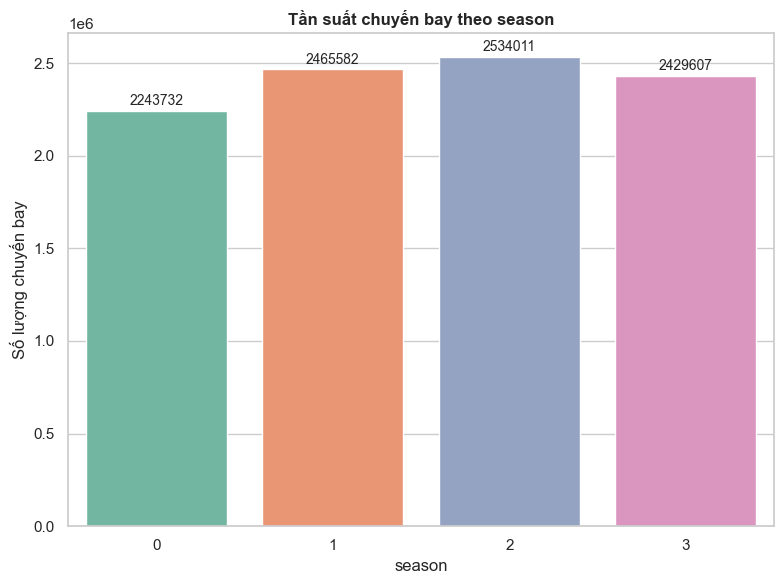

C:\Users\Pham Ngoc Minh\AppData\Local\Temp\ipykernel_39464\3235364544.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=train, x=col, palette='Set2')


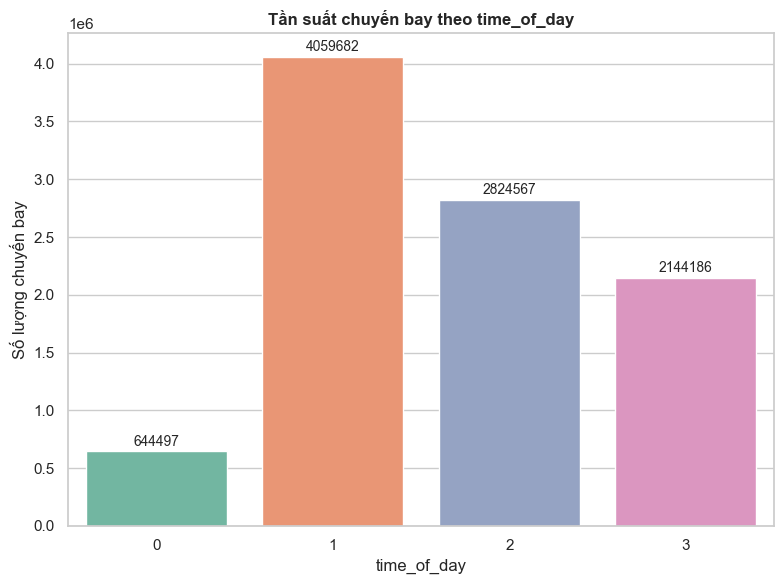

C:\Users\Pham Ngoc Minh\AppData\Local\Temp\ipykernel_39464\3235364544.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=train, x=col, palette='Set2')


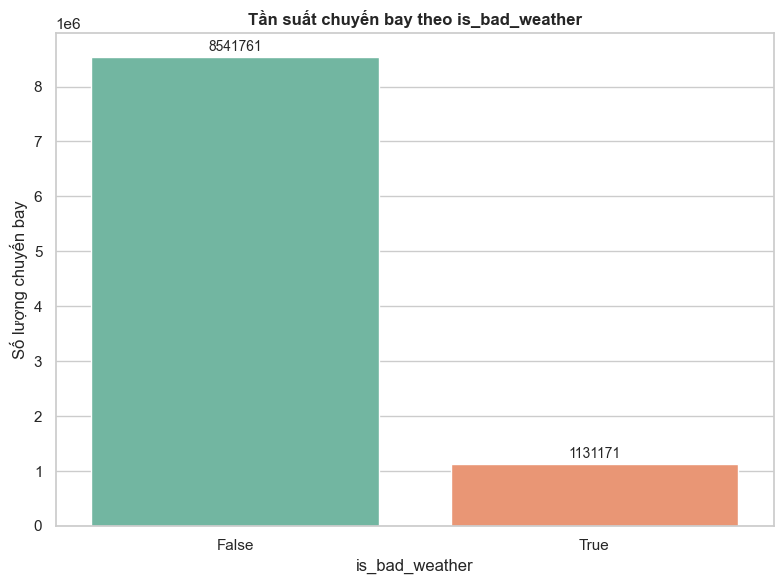

In [11]:
discrete_cols = ['season', 'time_of_day', 'is_bad_weather']

for col in discrete_cols:
    plt.figure(figsize=(8, 6))
    
    ax = sns.countplot(data=train, x=col, palette='Set2')
    
    ax.set_title(f'Tần suất chuyến bay theo {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Số lượng chuyến bay')
    ax.set_xlabel(col)
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', fontsize=10, 
                        xytext=(0, 2), textcoords='offset points')

    plt.tight_layout()
    plt.show()

**1. Tần suất chuyến bay theo season**

* Số lượng chuyến bay giữa các mùa khá đồng đều, dao động từ khoảng **2,24 triệu đến 2,53 triệu chuyến**.
* **Season 2** có số chuyến bay cao nhất (~2,53 triệu), trong khi **Season 0** thấp nhất (~2,24 triệu).
* Chênh lệch giữa các mùa không lớn, cho thấy dữ liệu được phân bố tương đối cân bằng theo mùa.
* Tuy nhiên, sự khác biệt nhỏ này vẫn có thể phản ánh ảnh hưởng của yếu tố mùa vụ đến tình trạng chậm chuyến và nên được giữ lại trong mô hình dự đoán.

---

**2. Tần suất chuyến bay theo is_bad_weather**

* Phần lớn các chuyến bay diễn ra trong điều kiện thời tiết bình thường (**~8,54 triệu chuyến**, chiếm khoảng 88%).
* Các chuyến bay gặp thời tiết xấu chỉ khoảng **1,13 triệu chuyến** (khoảng 12%).
* Dữ liệu bị mất cân bằng giữa hai nhóm, nhưng điều này phản ánh thực tế hoạt động hàng không.
* Vì thời tiết xấu là một trong những nguyên nhân chính gây chậm chuyến, biến **is_bad_weather** được kỳ vọng có ảnh hưởng đáng kể đến kết quả dự đoán độ trễ.

---

**3. Tần suất chuyến bay theo time_of_day**

* **Khung giờ 1** có số chuyến bay lớn nhất (~4,06 triệu chuyến), tiếp theo là **khung giờ 2** (~2,82 triệu) và **khung giờ 3** (~2,14 triệu).
* **Khung giờ 0** có ít chuyến bay nhất (~0,64 triệu), thấp hơn đáng kể so với các khung giờ còn lại.
* Điều này cho thấy hoạt động khai thác tập trung chủ yếu vào các khung giờ cao điểm trong ngày.
* Sự khác biệt về mật độ chuyến bay giữa các khung giờ có thể ảnh hưởng đến khả năng xảy ra chậm chuyến do tắc nghẽn khai thác, vì vậy **time_of_day** là một đặc trưng quan trọng trong bài toán dự đoán độ trễ chuyến bay.


C:\Users\Pham Ngoc Minh\AppData\Local\Temp\ipykernel_15664\3791937566.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_carrier_sorted_flights, x='Carrier', y='Total_Flights', ax=axes[0], palette='Blues_r')
C:\Users\Pham Ngoc Minh\AppData\Local\Temp\ipykernel_15664\3791937566.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_carrier_sorted_delay, x='Carrier', y='Mean_Delay', ax=axes[1], palette='Reds_r')


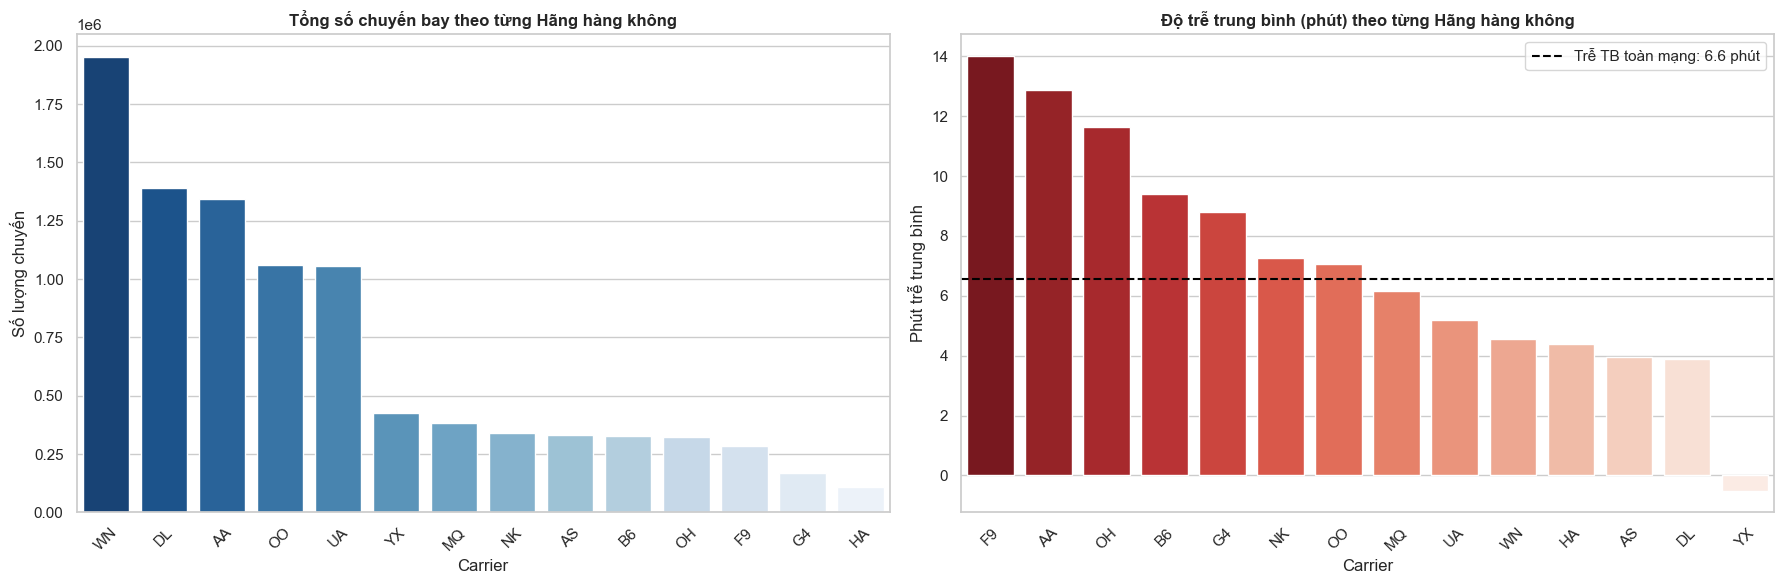

In [ ]:
carrier_cols = [col for col in train.columns if 'op_unique_carrier_' in col]

carrier_stats = []

for col in carrier_cols:
    carrier_name = col.replace('op_unique_carrier_', '')
    
    total_flights = train[col].sum()
    
    mean_delay = train[train[col] == 1]['arr_delay'].mean()
    
    carrier_stats.append({
        'Carrier': carrier_name,
        'Total_Flights': total_flights,
        'Mean_Delay': mean_delay
    })

df_carrier = pd.DataFrame(carrier_stats)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

df_carrier_sorted_flights = df_carrier.sort_values('Total_Flights', ascending=False)
sns.barplot(data=df_carrier_sorted_flights, x='Carrier', y='Total_Flights', ax=axes[0], palette='Blues_r')
axes[0].set_title('Tổng số chuyến bay theo từng Hãng hàng không', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Số lượng chuyến')
axes[0].tick_params(axis='x', rotation=45)

df_carrier_sorted_delay = df_carrier.sort_values('Mean_Delay', ascending=False)
sns.barplot(data=df_carrier_sorted_delay, x='Carrier', y='Mean_Delay', ax=axes[1], palette='Reds_r')
axes[1].set_title('Độ trễ trung bình (phút) theo từng Hãng hàng không', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Phút trễ trung bình')
axes[1].tick_params(axis='x', rotation=45)

global_mean_delay = train['arr_delay'].mean()
axes[1].axhline(global_mean_delay, color='black', linestyle='--', label=f'Trễ TB toàn mạng: {global_mean_delay:.1f} phút')
axes[1].legend()

plt.tight_layout()
plt.show()


**Tổng số chuyến bay theo từng hãng hàng không**

Biểu đồ cho thấy sự khác biệt đáng kể về quy mô khai thác giữa các hãng hàng không. Hãng **WN** có số lượng chuyến bay lớn nhất, đạt gần 2 triệu chuyến, vượt trội so với các hãng còn lại. Các hãng **DL, AA, OO và UA** cũng có tần suất khai thác cao với hơn 1 triệu chuyến bay trong tập dữ liệu. Trong khi đó, các hãng như **G4** và **HA** có quy mô hoạt động nhỏ hơn đáng kể. Sự chênh lệch này phản ánh đặc điểm hoạt động khác nhau giữa các hãng và cho thấy tập dữ liệu không phân bố đồng đều theo biến **Carrier**. Việc phân tích tần suất chuyến bay theo hãng giúp đánh giá mức độ đại diện của từng nhóm dữ liệu, đồng thời cho thấy hãng hàng không có thể là một yếu tố cần xem xét trong bài toán dự đoán độ trễ chuyến bay.

---

**Độ trễ trung bình theo từng hãng hàng không**

Biểu đồ cho thấy độ trễ trung bình có sự khác biệt rõ rệt giữa các hãng. **F9** là hãng có độ trễ trung bình cao nhất, khoảng 14 phút, tiếp theo là **AA** và **OH** với mức độ trễ đều vượt xa mức trung bình toàn mạng là 6,6 phút. Ngược lại, các hãng như **DL, AS, HA và WN** có độ trễ trung bình thấp hơn đáng kể so với mặt bằng chung. Đặc biệt, **YX** có giá trị độ trễ trung bình âm, cho thấy nhiều chuyến bay đến sớm hoặc đúng giờ hơn lịch trình. Kết quả này cho thấy hiệu suất khai thác và khả năng đảm bảo giờ bay có sự khác biệt giữa các hãng hàng không. Do đó, biến **Carrier** không chỉ mang ý nghĩa phân loại mà còn có khả năng cung cấp thông tin hữu ích cho mô hình dự đoán độ trễ, bởi mỗi hãng có đặc điểm vận hành và mức độ đúng giờ khác nhau.


C:\Users\Pham Ngoc Minh\AppData\Local\Temp\ipykernel_39464\827282625.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, ax=axes[1], palette='vlag')


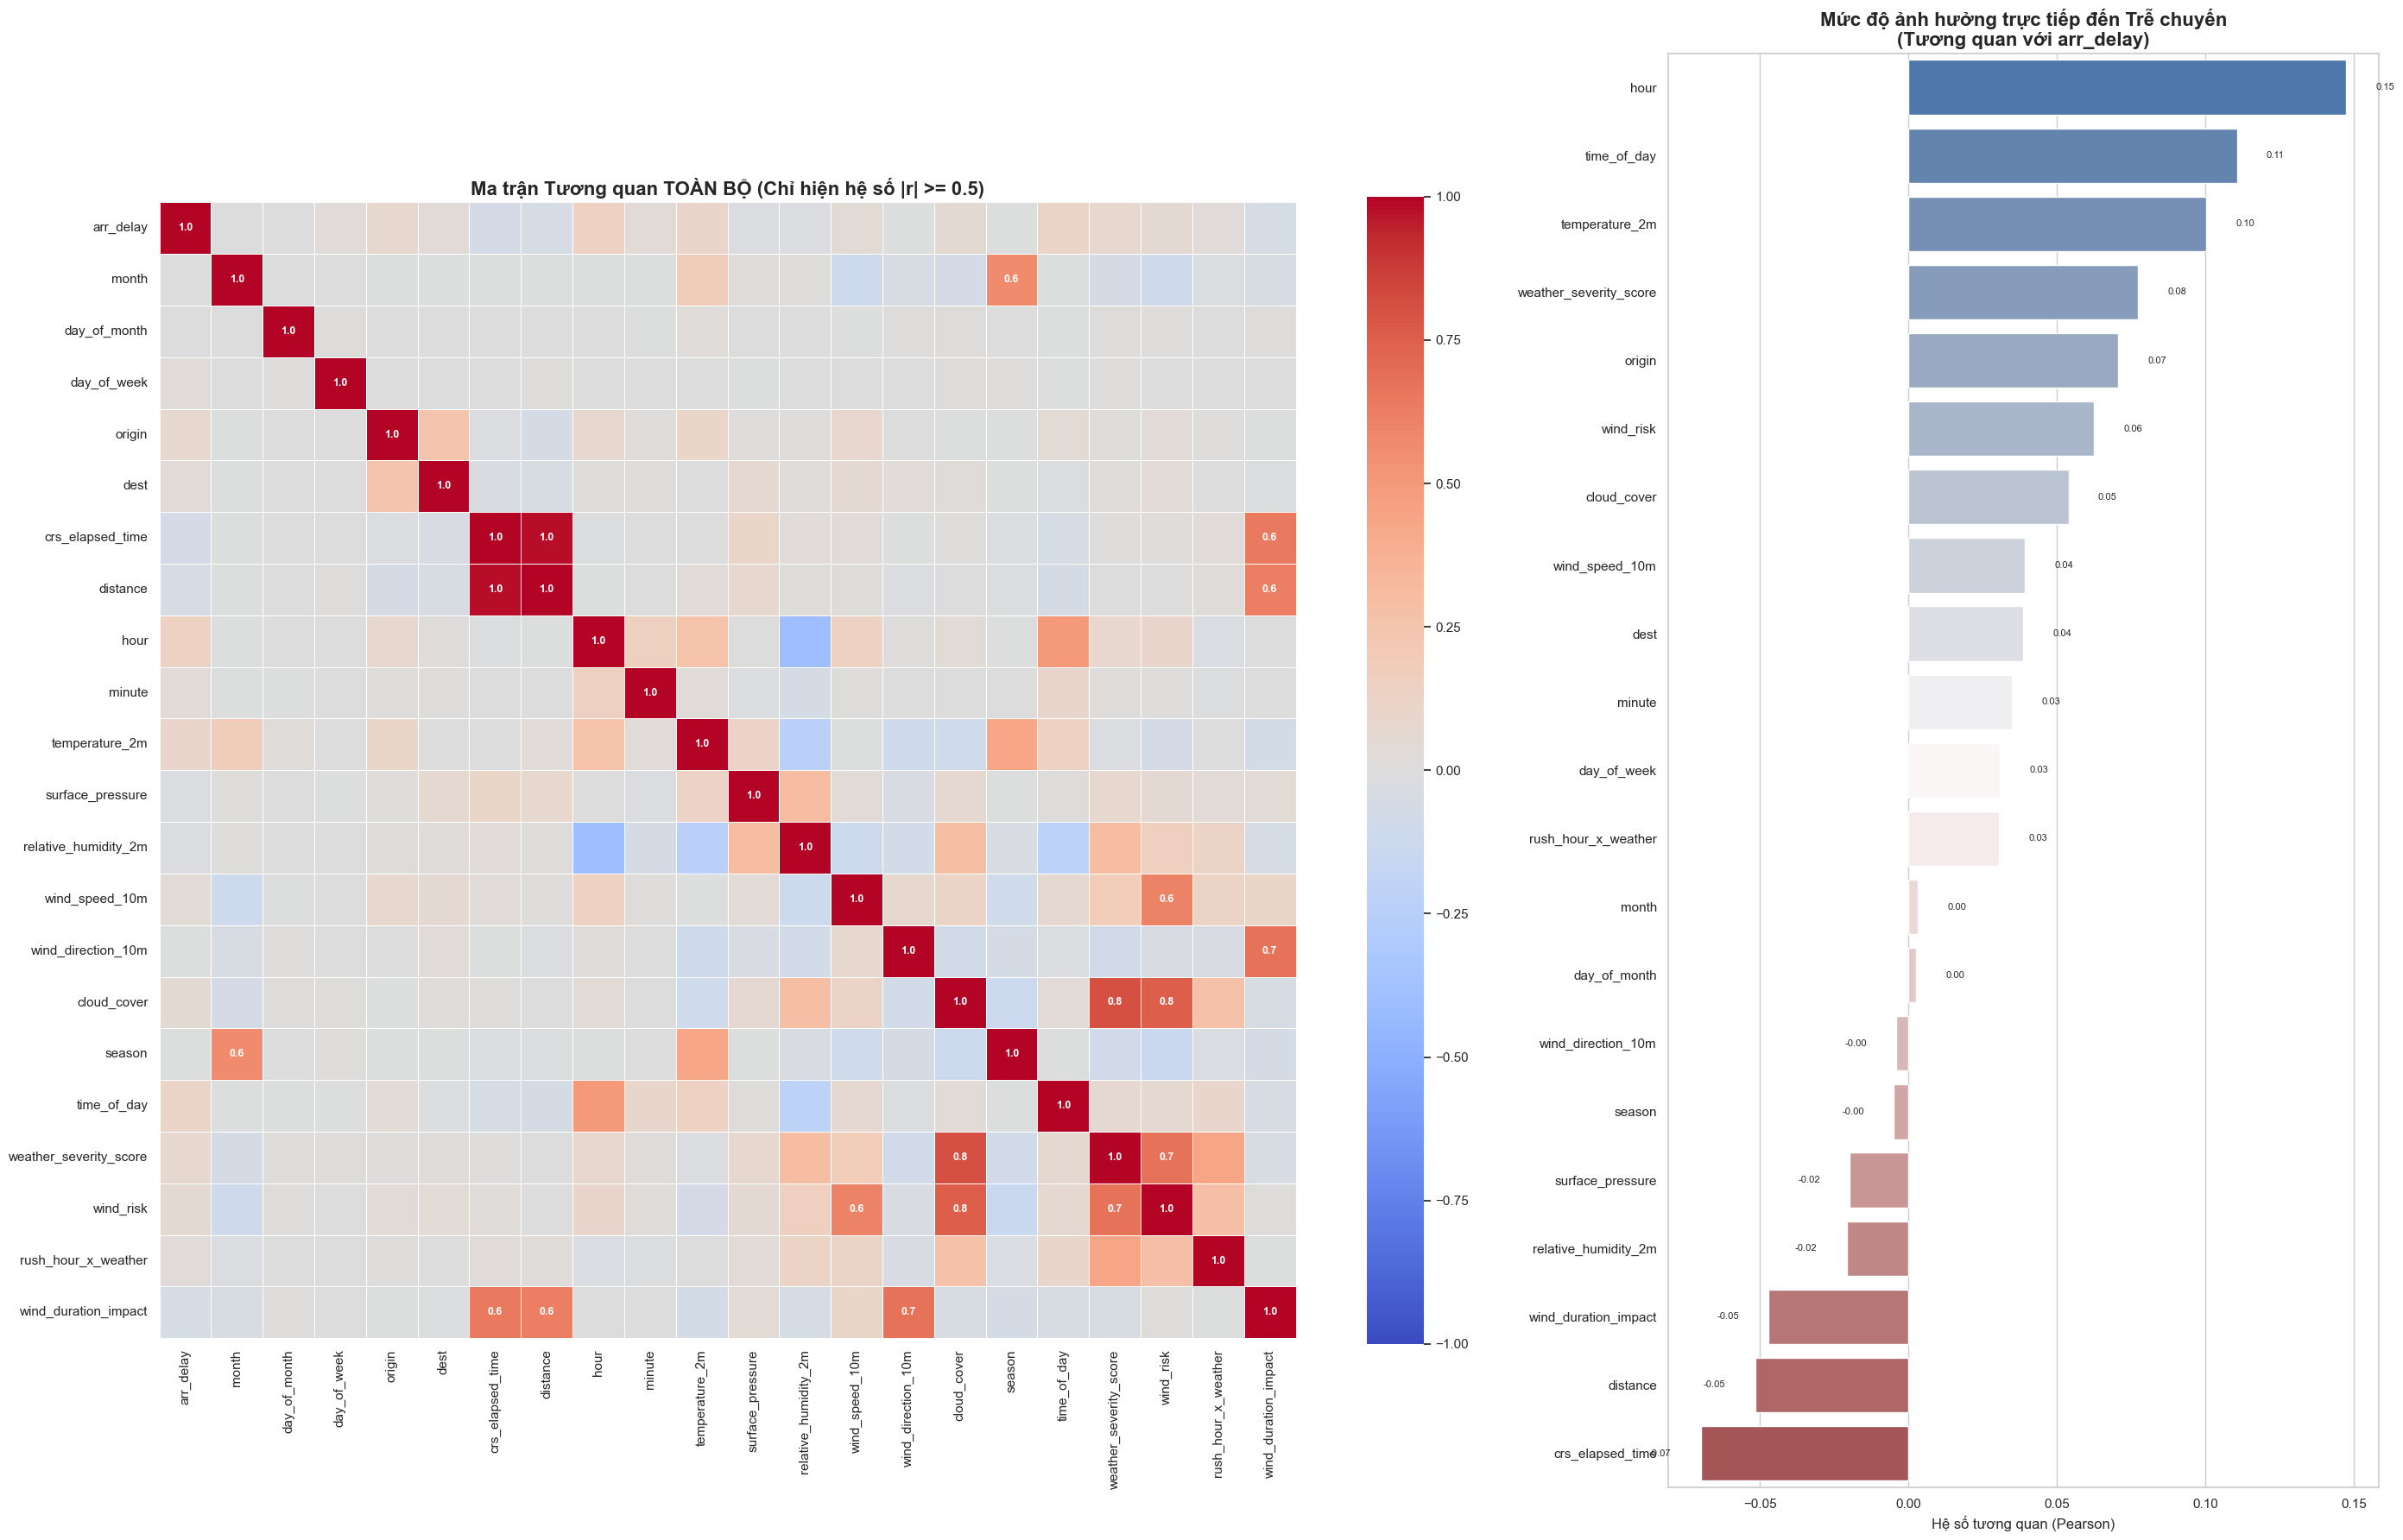

In [16]:
numeric_df = train.select_dtypes(include=[np.number])

cols = numeric_df.columns.tolist()
if 'arr_delay' in cols:
    cols.remove('arr_delay')
    cols = ['arr_delay'] + cols
    numeric_df = numeric_df[cols]

corr_matrix = numeric_df.corr()

threshold = 0.5
annot_matrix = np.where(np.abs(corr_matrix) >= threshold, 
                        np.round(corr_matrix, 1).astype(str), 
                        "")

fig, axes = plt.subplots(1, 2, figsize=(28, 18), gridspec_kw={'width_ratios': [2, 1]})

sns.heatmap(corr_matrix, mask=None, annot=annot_matrix, fmt="", cmap='coolwarm',
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5,
            cbar_kws={"shrink": .8}, ax=axes[0], annot_kws={"size": 9, "fontweight": "bold"})

axes[0].set_title(f'Ma trận Tương quan TOÀN BỘ (Chỉ hiện hệ số |r| >= {threshold})',
                  fontsize=16, fontweight='bold')

target_corr = corr_matrix['arr_delay'].drop('arr_delay').sort_values(ascending=False)

sns.barplot(x=target_corr.values, y=target_corr.index, ax=axes[1], palette='vlag')

axes[1].set_title('Mức độ ảnh hưởng trực tiếp đến Trễ chuyến\n(Tương quan với arr_delay)',
                  fontsize=16, fontweight='bold')
axes[1].set_xlabel('Hệ số tương quan (Pearson)', fontsize=12)
axes[1].set_ylabel('')

for p in axes[1].patches:
    width = p.get_width()
    ha = 'left' if width > 0 else 'right'
    offset = 0.01 if width > 0 else -0.01

    axes[1].annotate(f'{width:.2f}',
                     (width + offset, p.get_y() + p.get_height() / 2.),
                     ha=ha, va='center', fontsize=8)

plt.tight_layout()
plt.show()


Dựa vào ma trận tương quan cho thấy hầu hết các đặc trưng đều có mối liên hệ tuyến tính yếu với `arr_delay`, trong đó **hour** là biến có tương quan dương cao nhất (r ≈ 0.15), cho thấy các chuyến bay vào thời điểm muộn trong ngày có xu hướng bị trễ nhiều hơn do hiệu ứng trễ dây chuyền. Các yếu tố thời tiết như **weather_severity_score**, **wind_risk**, **temperature_2m** và **cloud_cover** cũng có tương quan dương nhưng ở mức thấp, phản ánh ảnh hưởng nhất định của điều kiện thời tiết đến độ trễ chuyến bay. Ngược lại, **crs_elapsed_time** và **distance** có tương quan âm nhẹ với `arr_delay`, cho thấy các chuyến bay dài thường có nhiều thời gian dự phòng hơn trong lịch trình khai thác. Ngoài ra, ma trận tương quan cho thấy **crs_elapsed_time** và **distance** có tương quan rất cao do cùng phản ánh đặc điểm của hành trình bay. Tuy nhiên, hai biến này vẫn được giữ lại vì mang ý nghĩa nghiệp vụ khác nhau và không gây ảnh hưởng đáng kể đến các mô hình cây như XGBoost và LightGBM. Nhìn chung, không có biến đơn lẻ nào quyết định độ trễ chuyến bay, cho thấy bài toán mang tính phi tuyến và phụ thuộc vào sự kết hợp của nhiều yếu tố khác nhau.


# OUTLIERS PROFILE

BẢNG TÓM TẮT HỒ SƠ NGOẠI LAI (OUTLIERS PROFILE):


,Đặc trưng,Ngưỡng trên (Upper Bound),Mốc 99%,Mốc 99.9%,Giá trị Max,Số lượng Ngoại lai,Tỷ lệ (%)
0,arr_delay,2.38,2.6,4.48,5.93,271010,2.80
1,distance,2077.00,2611.0,3801.00,5095.00,568434,5.88
2,wind_speed_10m,26.40,29.5,38.00,63.50,207952,2.15


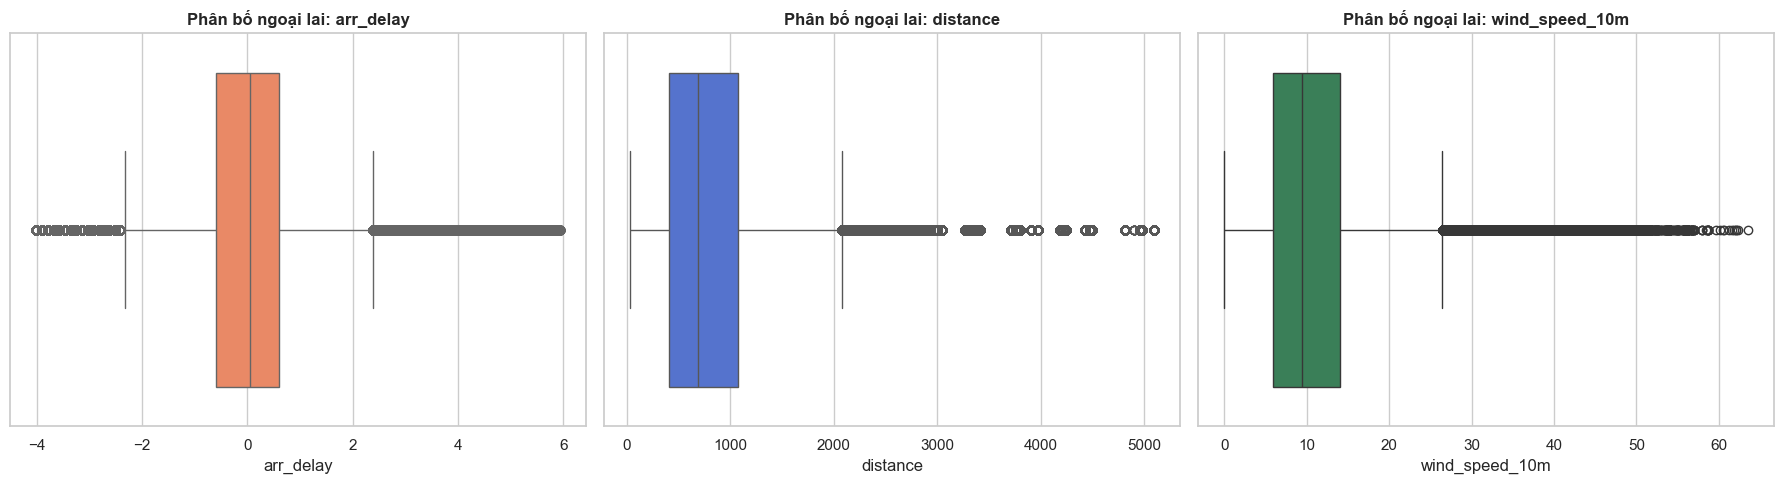

In [17]:

cont_cols = ['arr_delay', 'distance', 'wind_speed_10m']

outlier_summary = []
for col in cont_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_mask = (train[col] < lower_bound) | (train[col] > upper_bound)
    outliers_count = train[outliers_mask].shape[0]
    outliers_pct = (outliers_count / train.shape[0]) * 100
    
    p99 = train[col].quantile(0.99)
    p99_9 = train[col].quantile(0.999)
    max_val = train[col].max()
    
    outlier_summary.append({
        'Đặc trưng': col,
        'Ngưỡng trên (Upper Bound)': round(upper_bound, 2),
        'Mốc 99%': round(p99, 2),
        'Mốc 99.9%': round(p99_9, 2),
        'Giá trị Max': round(max_val, 2),
        'Số lượng Ngoại lai': outliers_count,
        'Tỷ lệ (%)': round(outliers_pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print("BẢNG TÓM TẮT HỒ SƠ NGOẠI LAI (OUTLIERS PROFILE):")
display(outlier_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['coral', 'royalblue', 'seagreen']

for i, col in enumerate(cont_cols):
    sns.boxplot(data=train, x=col, ax=axes[i], color=colors[i], showfliers=True)
    axes[i].set_title(f'Phân bố ngoại lai: {col}', fontsize=12, fontweight='bold')
    
plt.tight_layout()
plt.show()


**1. Đặc trưng arr_delay (Độ trễ chuyến bay)**
Đối với đặc trưng `arr_delay`, tỷ lệ ngoại lai chiếm 2.80% với ngưỡng trên là 2.38 và giá trị lớn nhất đạt 5.93. Dữ liệu phân bố tập trung chủ yếu quanh mức 0 cho thấy phần lớn các chuyến bay đều đúng giờ, nhưng lại bị lệch phải khá nặng. Mặc dù xuất hiện ngoại lai ở cả chiều đến sớm (giá trị âm) và chiều đến trễ (giá trị dương), phần lớn các điểm bất thường lại tạo thành một vệt phân bố dày đặc ở chiều bị trễ. Điều này phản ánh hiện tượng trễ chuyến nghiêm trọng xảy ra có tính hệ thống và là dữ liệu vận hành thực tế.

Do đó, giải pháp tối ưu là không xóa bỏ các điểm dữ liệu này. Nhóm lựa chọn áp dụng phép biến đổi **Yeo-Johnson**, khác với Logarit hay Box-Cox, Yeo-Johnson có khả năng xử lý mượt mà cả các giá trị âm (chuyến bay đến sớm) lẫn giá trị dương (trễ chuyến). Bước xử lý này giúp kéo phân phối của `arr_delay` về gần với phân phối chuẩn (normal distribution) hơn, làm giảm đi tác động của đuôi lệch phải. Nhờ vậy, dữ liệu hiện tại đã sẵn sàng để đưa vào huấn luyện, giúp các thuật toán (đặc biệt là nhóm mô hình tuyến tính) hoạt động ổn định và chính xác hơn mà không hề làm mất đi đặc tính thông tin gốc của các chuyến bay trễ.

**2. Đặc trưng distance (Khoảng cách chuyến bay)**
Đặc trưng `distance` ghi nhận tỷ lệ ngoại lai cao nhất ở mức 5.88%, với ngưỡng trên từ 2077 kéo dài đến mốc tối đa 5095. Biểu đồ cho thấy phần lớn dữ liệu tập trung đúc kết dưới mốc 1000, đại diện cho các chặng bay ngắn và trung bình, trong khi các điểm ngoại lai nằm đứt đoạn thành từng cụm rõ rệt ở vùng giá trị cực cao. Về bản chất, đây hoàn toàn không phải là dữ liệu lỗi hay dị thường mà chỉ mang ý nghĩa ngoại lai về mặt toán học so với số đông; thực chất, chúng đại diện cho nhóm thiểu số các chuyến bay đường dài hoặc xuyên lục địa. Phương án xử lý phù hợp là tuyệt đối giữ nguyên các giá trị này, đồng thời cân nhắc tạo thêm một biến phân loại (Categorical feature) để chia nhóm chặng bay (ngắn, trung, dài) nhằm giúp mô hình khai thác thông tin hiệu quả hơn.

**3. Đặc trưng wind_speed_10m (Tốc độ gió)**
Đặc trưng `wind_speed_10m` có tỷ lệ ngoại lai thấp nhất, chỉ chiếm 2.15%, nhưng lại có độ phân tán cực đoan ở mức cao khi khoảng cách từ ngưỡng trên 26.40 vọt lên giá trị lớn nhất 63.50 là rất xa. Phần lớn thời gian, tốc độ gió duy trì ở mức ôn hòa trong khoảng từ 5 đến 15, nhưng đuôi ngoại lai lại kéo dài liên tục và dày đặc về phía bên phải. Những điểm giá trị cao này phản ánh một cách chân thực các hiện tượng thời tiết cực đoan như bão hay gió giật mạnh, vốn là yếu tố tác động trực tiếp đến khả năng cất hạ cánh. Vì vậy, bắt buộc phải giữ nguyên khối dữ liệu này để mô hình có thể học được các rủi ro từ môi trường, và nên ưu tiên áp dụng các thuật toán Tree-based (như Random Forest, LightGBM) nhờ sự bền bỉ của chúng trước các giá trị biên khắc nghiệt.